# Learning by Pruning — Sensitivity Analysis

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
from torchvision import datasets
from itertools import product
from tqdm.auto import tqdm

from phd.research_utils.analysis.plotting import plot_param_sensitivity
from phd.jax_core.models import ltu

SEED = 262403
SCAN_UNROLL = 10
INPUT_SIZE = 784
OUTPUT_SIZE = 10

ACTIVATIONS = {
    'relu': jax.nn.relu,
    'ltu': ltu,
    'sigmoid': jax.nn.sigmoid,
}

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Load MNIST once ───────────────────────────────────────────────────
train_dataset = datasets.MNIST(root="./data", train=True, download=True)

all_images_np = train_dataset.data.numpy().reshape(-1, 784).astype(np.float32)
all_images_np = all_images_np / 255.0
all_labels_np = train_dataset.targets.numpy()
print(f"Loaded {len(all_labels_np)} training images")

Loaded 60000 training images


In [3]:
jax.nn.softmax(jnp.array([[0, 1, 2], [4, 4, 5]]), axis=1)

Array([[0.09003057, 0.24472848, 0.6652409 ],
       [0.21194157, 0.21194157, 0.57611686]], dtype=float32)

In [14]:
# ── Experiment function ───────────────────────────────────────────────

def forward(x, W1, W2, mask, act_fn):
    h = act_fn(x @ W1) * mask
    logits = h @ W2
    return logits, h


# 0. LOO effect on cross-entropy
def compute_utility_v0(h, W2, logits, label):
    # Counterfactual logits when each hidden unit i is removed
    c = W2 * h[:, None]  # (in, out) — contribution of unit i to each logit
    logits_wo = logits[None, :] - c  # (in, out)

    # Log-probs with and without each unit
    log_probs = jax.nn.log_softmax(logits)  # (out,)
    log_probs_wo = jax.nn.log_softmax(logits_wo, axis=1)  # (in, out)
    
    cross_entropy = -log_probs[label]
    cross_entropy_wo = -log_probs_wo[:, label]
    
    U = cross_entropy_wo - cross_entropy # (in,)
    
    return U


def compute_utility_bce_multi(h, W2, logits, label):
    # h: (in,), W2: (in, out), logits: (out,), labels: (out,) in {0, 1}
    c = W2 * h[:, None]                    # (in, out)
    logits_wo = logits[None, :] - c        # (in, out)

    labels = jax.nn.one_hot(label, logits.shape[0])
    
    log_probs = labels * jax.nn.log_sigmoid(logits) + (1 - labels) * jax.nn.log_sigmoid(-logits)           # (out,)
    log_probs_wo = labels * jax.nn.log_sigmoid(logits_wo) + (1 - labels) * jax.nn.log_sigmoid(-logits_wo)  # (in, out)

    # Sum BCE across outputs (standard multi-label reduction)
    cross_entropy = -log_probs
    cross_entropy_wo = -log_probs_wo
    
    U = jnp.sum(cross_entropy_wo - cross_entropy[None, :], axis=1) # (in,)

    return U


def compute_utility_tanh_multi(h, W2, logits, label):
    # h: (in,), W2: (in, out), logits: (out,), label: scalar class index
    c = W2 * h[:, None]                    # (in, out)
    logits_wo = logits[None, :] - c        # (in, out)

    # Map class index to ±1 targets: true class → +1, others → -1
    one_hot = jax.nn.one_hot(label, logits.shape[0])
    targets = 2 * one_hot - 1              # (out,) in {-1, +1}

    # log p(y | z) = log σ(2 y z) = -softplus(-2 y z) = log_sigmoid(2 y z)
    log_probs    = jax.nn.log_sigmoid(2 * targets * logits)              # (out,)
    log_probs_wo = jax.nn.log_sigmoid(2 * targets * logits_wo)           # (in, out)

    U = jnp.sum(-log_probs_wo - (-log_probs)[None, :], axis=1)  # (in,)
    return U


UTIL_FN = compute_utility_tanh_multi


def _make_scan_step(trace_decay, act_fn):
    """Create a scan step function closed over trace_decay and activation."""
    def _scan_step(carry, data):
        W1, W2, mask, utility_trace = carry
        x, label = data
        logits, h = forward(x, W1, W2, mask, act_fn)
        correct = (jnp.argmax(logits) == label).astype(jnp.float32)

        U = UTIL_FN(h, W2, logits, label)

        utility_trace = utility_trace * trace_decay + U * (1 - trace_decay)
        carry = (W1, W2, mask, utility_trace)
        return carry, correct
    return _scan_step


# Cache of jitted scan functions keyed by (trace_decay, activation_name)
_scan_cache = {}

def _get_scan_fn(trace_decay, activation='relu'):
    cache_key = (trace_decay, activation)
    if cache_key not in _scan_cache:
        act_fn = ACTIVATIONS[activation]
        step_fn = _make_scan_step(trace_decay, act_fn)
        _scan_cache[cache_key] = jax.jit(
            lambda carry, data: jax.lax.scan(step_fn, carry, data, unroll=SCAN_UNROLL)
        )
    return _scan_cache[cache_key]


def run_pruning_experiment(
    hidden_size,
    prune_every,
    reset_traces_on_prune,
    activation='relu',
    seed=SEED,
    pbar=None,
):
    """Run a single learning-by-pruning experiment. Returns dict of results."""
    trace_decay = 1.0 - (1.0 / prune_every)
    n_prune_events = hidden_size

    scan_fn = _get_scan_fn(trace_decay, activation)

    # LeCun uniform initializer, no biases
    key = jax.random.PRNGKey(seed)
    k1, k2 = jax.random.split(key)
    # Lecun uniform: U(-sqrt(3 / fan_in), sqrt(3 / fan_in))
    lim1 = np.sqrt(3.0 / INPUT_SIZE)
    lim2 = np.sqrt(3.0 / hidden_size)
    W1 = jax.random.uniform(k1, (INPUT_SIZE, hidden_size), minval=-lim1, maxval=lim1)
    W2 = jax.random.uniform(k2, (hidden_size, OUTPUT_SIZE), minval=-lim2, maxval=lim2)
    mask = jnp.ones(hidden_size)
    utility_trace = jnp.zeros(hidden_size)

    # Data iteration
    rng = np.random.RandomState(seed)
    epoch_order = rng.permutation(len(all_labels_np))
    epoch_pos = 0

    def get_chunk(size):
        nonlocal epoch_order, epoch_pos
        indices = []
        remaining = size
        while remaining > 0:
            avail = len(epoch_order) - epoch_pos
            take = min(avail, remaining)
            indices.append(epoch_order[epoch_pos:epoch_pos + take])
            epoch_pos += take
            remaining -= take
            if epoch_pos >= len(epoch_order):
                epoch_order = rng.permutation(len(all_labels_np))
                epoch_pos = 0
        return np.concatenate(indices)

    all_corrects = []
    n_active_history = []
    # Remove biases from carry
    carry = (W1, W2, mask, utility_trace)

    for prune_idx in range(n_prune_events):
        indices = get_chunk(prune_every)
        data = (jnp.array(all_images_np[indices]), jnp.array(all_labels_np[indices]))

        carry, corrects = scan_fn(carry, data)
        all_corrects.append(np.array(corrects))

        W1, W2, mask, utility_trace = carry
        n_active = int(mask.sum())
        n_active_history.append(n_active)

        if n_active > 1:
            score = jnp.where(mask > 0.5, utility_trace, jnp.inf)
            worst = jnp.argmin(score)
            mask = mask.at[worst].set(0.0)
            if reset_traces_on_prune:
                utility_trace = jnp.zeros(hidden_size)

        carry = (W1, W2, mask, utility_trace)

        if pbar is not None:
            pbar.update(prune_every)

    # Compute per-interval accuracy
    acc_per_interval = np.array([c.mean() for c in all_corrects])

    return {
        'acc_per_interval': acc_per_interval,
        'n_active_history': np.array(n_active_history),
        'peak_accuracy': float(acc_per_interval.max()) * 100,
        'mean_accuracy': float(acc_per_interval.mean()) * 100,
        'final_accuracy': float(acc_per_interval[-1]) * 100,
    }

In [15]:
EVAL_CHUNK = 1000  # steps per evaluation chunk; best chunk = reported metric

def best_chunk_accuracy(acc_per_interval, prune_every):
    """Average accuracy over the best EVAL_CHUNK-step window."""
    all_correct = np.concatenate([np.full(int(prune_every), a) for a in acc_per_interval])
    n_steps = len(all_correct)
    n_chunks = n_steps // EVAL_CHUNK
    if n_chunks == 0:
        return float(all_correct.mean()) * 100
    # Trim to exact multiple of EVAL_CHUNK
    trimmed = all_correct[:n_chunks * EVAL_CHUNK].reshape(n_chunks, EVAL_CHUNK)
    chunk_accs = trimmed.mean(axis=1)
    return float(chunk_accs.max()) * 100


def run_sweep(configs):
    """
    Run experiments for a list of config dicts.
    Each config must have: hidden_size, prune_every, reset_traces_on_prune.
    Optional: activation (default 'relu'), seed (default SEED).

    Returns (run_df, config_df) suitable for plot_param_sensitivity.
    run_df has one row per run with the best-EVAL_CHUNK accuracy as the metric.
    """
    run_rows = []
    config_rows = []

    total_steps = sum(cfg['hidden_size'] * cfg['prune_every'] for cfg in configs)
    pbar = tqdm(total=total_steps, desc='Sweep', unit='step')

    for run_id, cfg in enumerate(configs):
        hidden_size = cfg['hidden_size']
        prune_every = cfg['prune_every']
        reset = cfg['reset_traces_on_prune']
        activation = cfg.get('activation', 'relu')
        seed = cfg.get('seed', SEED)

        pbar.set_postfix(h=hidden_size, p=prune_every, reset=reset, act=activation)

        result = run_pruning_experiment(
            hidden_size=hidden_size,
            prune_every=prune_every,
            reset_traces_on_prune=reset,
            activation=activation,
            seed=seed,
            pbar=pbar,
        )

        best_acc = best_chunk_accuracy(result['acc_per_interval'], prune_every)

        run_rows.append({
            'run_id': run_id,
            'step': 0,
            'best_chunk_accuracy': best_acc,
        })

        config_rows.append({
            'run_id': run_id,
            'hidden_size': hidden_size,
            'prune_every': prune_every,
            'reset_traces_on_prune': reset,
            'activation': activation,
            'seed': seed,
        })

    pbar.close()

    run_df = pd.DataFrame(run_rows)
    config_df = pd.DataFrame(config_rows)
    return run_df, config_df

## Experiment 1: Hidden Size Sensitivity (ReLU)

How does the number of initial hidden units affect peak pruning performance? Larger networks have more units to prune through, giving the utility signal more opportunities to identify useful features — but they also require more total steps (hidden_size × prune_every). Each point shows the best 1k-step chunk accuracy achieved during the run, with separate lines for whether utility traces are reset after each prune event.

In [16]:
hidden_sizes = [100, 200, 400, 800, 1600, 3200]
reset_values = [False, True]

configs_exp1_relu = [
    {'hidden_size': h, 'prune_every': 100, 'reset_traces_on_prune': r, 'activation': 'relu'}
    for h, r in product(hidden_sizes, reset_values)
]

run_df_1_relu, config_df_1_relu = run_sweep(configs_exp1_relu)

Sweep: 100%|██████████| 1260000/1260000 [01:39<00:00, 12712.92step/s, act=relu, h=3200, p=100, reset=1]


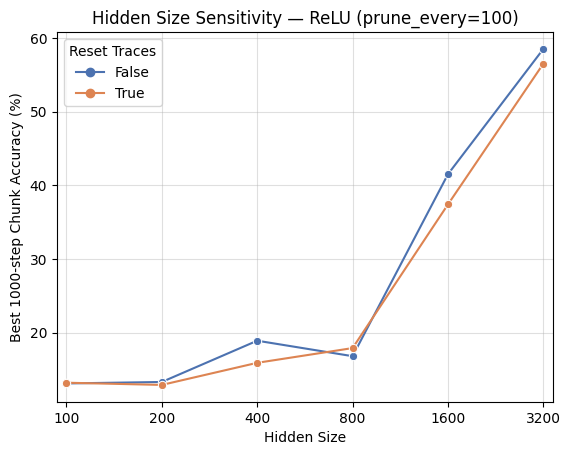

In [17]:
plot_param_sensitivity(
    run_df=run_df_1_relu,
    config_df=config_df_1_relu,
    x_col='hidden_size',
    hue_col='reset_traces_on_prune',
    metric_col='best_chunk_accuracy',
    metric_type='last',
    title='Hidden Size Sensitivity — ReLU (prune_every=100)',
    x_label='Hidden Size',
    y_label=f'Best {EVAL_CHUNK}-step Chunk Accuracy (%)',
    legend_title='Reset Traces',
)

## Experiment 1b: Hidden Size Sensitivity (LTU)

Same sweep as above but with the Linear Threshold Unit (step function forward, sigmoid gradient backward). LTU outputs are binary (0 or 1), so the utility signal may behave differently — units either fully contribute or not at all.

In [18]:
configs_exp1_ltu = [
    {'hidden_size': h, 'prune_every': 100, 'reset_traces_on_prune': r, 'activation': 'ltu'}
    for h, r in product(hidden_sizes, reset_values)
]

run_df_1_ltu, config_df_1_ltu = run_sweep(configs_exp1_ltu)

Sweep: 100%|██████████| 1260000/1260000 [01:36<00:00, 13040.32step/s, act=ltu, h=3200, p=100, reset=1]


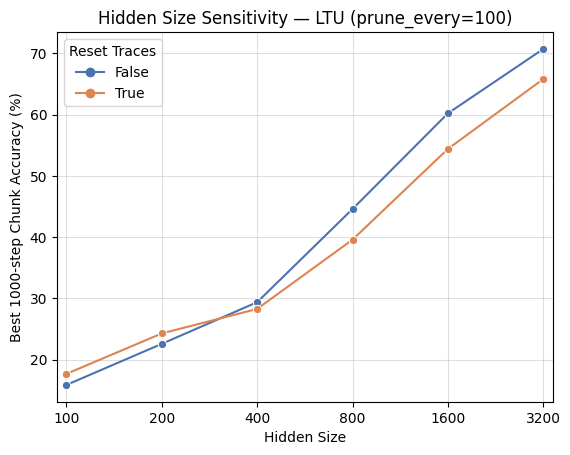

In [19]:
plot_param_sensitivity(
    run_df=run_df_1_ltu,
    config_df=config_df_1_ltu,
    x_col='hidden_size',
    hue_col='reset_traces_on_prune',
    metric_col='best_chunk_accuracy',
    metric_type='last',
    title='Hidden Size Sensitivity — LTU (prune_every=100)',
    x_label='Hidden Size',
    y_label=f'Best {EVAL_CHUNK}-step Chunk Accuracy (%)',
    legend_title='Reset Traces',
)

## Experiment 2: Prune Frequency Sensitivity (ReLU)

How many steps should elapse between pruning events? Too few steps means the utility trace hasn't accumulated enough signal to make a good pruning decision; too many means we waste compute on units that could have been pruned earlier. Hidden size is fixed at 1000. Each point shows the best 1k-step chunk accuracy, with separate lines for reset vs. no-reset of utility traces after pruning.

In [20]:
prune_every_values = [25, 50, 100, 200, 400, 800]

configs_exp2_relu = [
    {'hidden_size': 1000, 'prune_every': p, 'reset_traces_on_prune': r, 'activation': 'relu'}
    for p, r in product(prune_every_values, reset_values)
]

run_df_2_relu, config_df_2_relu = run_sweep(configs_exp2_relu)

Sweep: 100%|██████████| 3150000/3150000 [01:38<00:00, 32139.53step/s, act=relu, h=1000, p=800, reset=1]


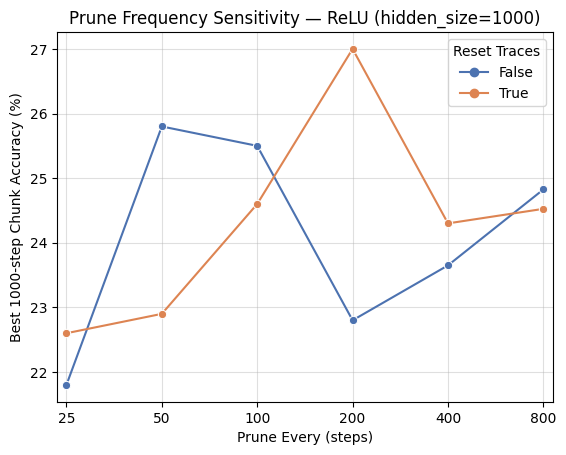

In [21]:
plot_param_sensitivity(
    run_df=run_df_2_relu,
    config_df=config_df_2_relu,
    x_col='prune_every',
    hue_col='reset_traces_on_prune',
    metric_col='best_chunk_accuracy',
    metric_type='last',
    title='Prune Frequency Sensitivity — ReLU (hidden_size=1000)',
    x_label='Prune Every (steps)',
    y_label=f'Best {EVAL_CHUNK}-step Chunk Accuracy (%)',
    legend_title='Reset Traces',
)

## Experiment 2b: Prune Frequency Sensitivity (LTU)

Same prune frequency sweep with LTU activation. Since LTU outputs are binary, the utility signal is simpler — a unit's contribution is either its full outgoing weight or zero. This may make the utility estimate more stable across different prune intervals.

In [22]:
configs_exp2_ltu = [
    {'hidden_size': 1000, 'prune_every': p, 'reset_traces_on_prune': r, 'activation': 'ltu'}
    for p, r in product(prune_every_values, reset_values)
]

run_df_2_ltu, config_df_2_ltu = run_sweep(configs_exp2_ltu)

Sweep: 100%|██████████| 3150000/3150000 [01:38<00:00, 32076.39step/s, act=ltu, h=1000, p=800, reset=1]


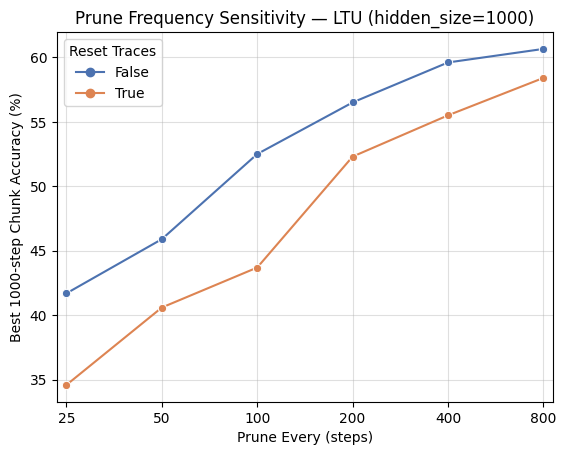

In [23]:
plot_param_sensitivity(
    run_df=run_df_2_ltu,
    config_df=config_df_2_ltu,
    x_col='prune_every',
    hue_col='reset_traces_on_prune',
    metric_col='best_chunk_accuracy',
    metric_type='last',
    title='Prune Frequency Sensitivity — LTU (hidden_size=1000)',
    x_label='Prune Every (steps)',
    y_label=f'Best {EVAL_CHUNK}-step Chunk Accuracy (%)',
    legend_title='Reset Traces',
)